<a href="https://colab.research.google.com/github/natalianowak1/airbnb-price-optimization/blob/main/airbnb_price_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Przygotowanie środowiska i import bibliotek



In [372]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Wczytanie i wstępny przegląd danych

In [373]:
df = pd.read_excel("/content/2026-06-06 Airbnb_Open_Data.xlsx")

###2.1. Podgląd pierwszych pięciu wierszy

In [374]:
pd.set_option('display.max_columns', None)
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

   latitude  longitude        country country code  instant_bookable  \
0  40.64749  -73.97237  United S

###2.2. Identyfikacja zmiennych i weryfikacja typów

In [375]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   latitude                        102591 non-null  float64
 8   longitude                       102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  float64
 12  cancellation_pol

###2.3. Zliczanie brakujących wartości (nulli) w każdej kolumnie

In [376]:
print(df.isnull().sum())

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
latitude                               8
longitude                              8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          632
minimum nights                       409
number of reviews                    183
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules                        52131
license         

###2.4. Sprawdzenie ilości w pełni zduplikowanych wierszy

In [377]:
print(f"Liczba zduplikowanych wierszy: {df.duplicated().sum()}")

Liczba zduplikowanych wierszy: 541


###2.5. Wnioski ze wstępnej analizy:
####2.5.1. Metryki ogólne:
*  Tabela zawiera 25 kolumnn o nazwach kolejno: 'id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'latitude', 'longitude', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license'
* Tabela liczy 102 599 wierszy (ogłoszeń).
* W zbiorze wykryto 541 całkowicie zduplikowanych wierszy, które należy usunąć.
* Jedyne kolumny, które są w 100% kompletne (0 nulli), to: `id`, `host id` oraz `room type`. W pozostałych 22 kolumnach występują nulle.

####2.5.2. Na podstawie wstępnego przeglądu identyfikuję następujące zmienne rynkowe, które w dalszych krokach zostaną zbadane pod kątem wpływu na cenę:
* LOKALIZACJA:
   - 'neighbourhood group' (Główny obszar/dzielnica, np. Manhattan, Brooklyn)
   - 'neighbourhood' (Konkretne osiedle)
   - 'latitude', 'longitude' (Współrzędne geograficzne do mapowania)
* CECHY REZERWACJI I NIERUCHOMOŚCI:
   - 'room type' (Rodzaj pokoju: całe miejsce, pokój prywatny, itp.)
   - 'Construction year' (Rok budowy nieruchomości - potencjalny wpływ na standard i cenę)
   - 'instant bookable' (Czy nieruchomość można zarezerwować od ręki)
   - 'cancellation_policy' (Szczegóły dotyczące zasad anulowania rezerwacji)
   - 'minimum nights' (Minimalna liczba nocy wymagana przez gospodarza przy rezerwacji)
   - 'availability 365' (Liczba dni, w które nieruchomość jest dostępna do rezerwacji w ciągu roku)
  
* DOŚWIADCZENIE I STATUS GOSPODARZA:
   - 'review rate number' (Numeryczna ocena na podstawie recenzji)
   - 'number of reviews' (Łączna liczba recenzji)
   - 'reviews per month' (Średnia liczba recenzji na miesiąc)
   - 'calculated host listings count' (Łączna liczba ogłoszeń gospodarza)

####2.5.3. Zidentyfikowane anomalie i plan ich czyszczenia:
* Zbiór danych charakteryzuje się brakiem spójności w nazwach kolumn (część pisana wielkimi literami, stosowanie spacji na zmianę z podkreśleniami/podłogami). Aby uprosćić kod w Pythonie (zamiast konieczności pisania "df['host id']", można pisać: "df.host_id") oraz zapewnić spójność, nazwy kolumn należy zamienić do formatu `pierwszesłowo_drugiesłowo` (małe litery, spacje zastąpione znakiem `_`).
*   Kolumna 'price' (cena) jest już zapisana jako dana liczbowe (float64), co umożliwia bezpośrednie wykonywanie obliczeń i analizę statystyczną. Kolumna 'service fee' (opłata serwisowa) ma typ danych object, należy zmienić na float64 począwszy od usunięcia znaku "$". Kolumny te posiadają jednak kolejno po 247 i 632 braków danych, które trzeba uzupełnić (np. medianą cen).
* Kolumna `instant_bookable` zawiera wartości binarne (1 i 0) oraz 105 nulli. W etapie czyszczenia należy zastąpić nulle wartością `0` (bezpieczne założenie, że brak informacji oznacza brak natychmiastowej rezerwacji), a całą kolumnę zmienić na typ logiczny (`boolean`).
* Kolumna `reviews per month` zawiera aż 15 879 braków danych. Wynika to z faktu, że nowo dodane nieruchomości nie mają jeszcze żadnych opinii. Nulle w tej kolumnie zostaną zastąpione wartością `0.0`.
* Kolumna `license` zawiera tylko 2 wypełnione wiersze, a cała reszta to nulle (kolumna kwalifikuje się do usunięcia).
* Kolumna `house_rules` nie będzie rozważana względem wpływu na cenę i kwalifikuje się do usunięcia.
* Kolumna `house_rules` zawiera informacje w mniej niż połowie wierszy (52 131 nulli). Braki zostaną zastąpione wartością domyślną "No rules specified".
* Należy wykonać korektę kolumn lokalizacyjnych (`country` i `country code`) Ponieważ cały zbiór danych dotyczy rynku w Nowym Jorku, braki danych w kolumnie kraju i jego kodu zostaną uzupełnione stałymi wartościami (odpowiednio: "United States" oraz "US")
* Kolumna `host_identity_verified` posiada 289 nulli. Zostanie tam wprowadzona kategoria "unconfirmed", co jest bezpieczniejszym podejściem biznesowym niż zakładanie, że profil jest zweryfikowany
* Wykryto po 8 braków danych w pozycjach geograficznych (`latitude`, `longitude`). Ponieważ te współrzędne są kluczowe do poprawnego renderowania map w Tableau, wiersze z tymi brakami zostaną całkowicie usunięte z bazy
* Kolumna `neigbhourhood group` posiada 29 braków. W wierszu gdzie jest brak w `neigbhourhood group` i mamy daną w `neighbourhood`, brak w  `neighbourhood_group` można dobrać na podstawie innych dopasowań, pozostałe wiersze z nullami zostaną zastąpione wartością "Unknown".
* Pozostałe kolumny tekstowe i lokalizacyjne (np. `NAME`, `host name`, `neighbourhood`) posiadają niewielkie liczby braków (od kilku do kilkuset). W ich przypadku wiersze z nullami zostaną zastąpione wartością "Unknown".



# 3. Czyszczenie danych (Data Cleaning)


####3.1. Usuwanie całkowicie zduplikowanych wierszy

In [378]:
print(f"Liczba wierszy przed usunięciem duplikatów: {len(df)}")
df = df.drop_duplicates()
print(f"Liczba wierszy po usunięciu duplikatów: {len(df)}\n")

Liczba wierszy przed usunięciem duplikatów: 102599
Liczba wierszy po usunięciu duplikatów: 102058



####3.2. Usuwanie wierszy, które mają nulle w `latitude` lub `longitude`

In [379]:
print(f"Liczba wierszy przed usunięciem braków w geolokalizacji: {len(df)}")
df = df[(df['latitude'].notnull()) & (df['longitude'].notnull())]
print(f"Liczba wierszy po usunięciu braków w geolokalizacji: {len(df)}")

Liczba wierszy przed usunięciem braków w geolokalizacji: 102058
Liczba wierszy po usunięciu braków w geolokalizacji: 102050


####3.3. Usuwanie kolumny `license` i `house_rules`

In [380]:
df = df.drop(columns=['license', 'house_rules'])
print(f"Nowa liczba kolumn w tabeli: {len(df.columns)}")

Nowa liczba kolumn w tabeli: 23


####3.4. Zmiana nazw kolumn do formatu "snake_case"

In [381]:
print(list(df.columns))
#zamiana liter z wielkich ma małe
df.columns = df.columns.str.lower()
#zamiana spacji w nazwach kolumn na podkreślenie
df.columns = df.columns.str.replace(' ', '_')
print(list(df.columns))

['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'latitude', 'longitude', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365']
['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365']


####3.4. Werfyikacja czy nie mamy duplikatów w kolumnie id ogłodzenia

In [382]:
print("Liczba zdublowanych ID:", df['id'].duplicated().sum())

Liczba zdublowanych ID: 0


####3.5. Zastępowanie braków w kolumnach `name`wartością "Unknown"

In [383]:
print(f"Liczba nulli w name przed uzupełnieniem: {df.name.isnull().sum()}")
df['name'] = df['name'].fillna("Unknown")
print(f"Liczba nulli w name: {df.name.isnull().sum()}")

Liczba nulli w name przed uzupełnieniem: 250
Liczba nulli w name: 0


####3.6. Zastępowanie braków w kolumnach `host_name` wartością "Unknown"

In [384]:
print(f"Liczba nulli w host_name przed uzupełnieniem: {df.host_name.isnull().sum()}\n")
df['host_name'] = df['host_name'].fillna("Unknown")
print(f"Liczba nulli w host_name: {df.host_name.isnull().sum()}")

Liczba nulli w host_name przed uzupełnieniem: 404

Liczba nulli w host_name: 0


####3.7. Sprawdzenie unikalnych wartości dla kolumny `host_identity_verified`: uzupełnienie nulli wartością "unconfirmed".
Założenie, że brak danych oznacza że gospodarz pojawia się w bazie tylko raz i nie ma jak ściągnąć jego statusu po host_id, z resztą przy ilości nulli to jest za dużo pisania kodu względem ilości potencjalnie odzyskanych danych. Założenie, że brak danych oznacza, że gospodarz nie jest zweryfikowany.

In [385]:
print("Unikalne wartości w host_identity_verified: ", df.host_identity_verified.unique())
print(f"Liczba nulli w host_identity_verified przed uzupełnieniem: {df.host_identity_verified.isnull().sum()}\n")
df['host_identity_verified'] = df['host_identity_verified'].fillna("unconfirmed")
print(f"Liczba nulli w host_identity_verified: {df.host_identity_verified.isnull().sum()}")

Unikalne wartości w host_identity_verified:  ['unconfirmed' 'verified' nan]
Liczba nulli w host_identity_verified przed uzupełnieniem: 289

Liczba nulli w host_identity_verified: 0


####3.8. Sprawdzenie unikalnych wartości, ujednolicanie wartości i zastępowanie braków w kolumnach `neighbourhood_group` wartością z dopasowań z kolumny `neighbourhood` gdzie jest dana i  wartością "Unknown" tam gdzie w obu kolumnach mamy brak danych.

In [386]:
print("Unikalne dzielnice główne przed korektą:", df.neighbourhood_group.unique())
#brak ukrytych spacji, ale należy ujednolicić nazwy dzielnic Brooklyn i Manhattan do formatu "Dzielnica" i pozbyć się literówe
neighbourhood_group_repair = {
    'brookln': 'Brooklyn',
    'manhatan': 'Manhattan'
}
df['neighbourhood_group'] = df.neighbourhood_group.replace(neighbourhood_group_repair)
print(f"Unikalne dzielnice główne po korekcie: {df.neighbourhood_group.unique()}\n")

print(f"Liczba nulli w kolumnie neughbourhood_group przed dopasowaniem z neighbourhood: {df.neighbourhood_group.isnull().sum()}")

# Stworzenie słownika mapującego osiedla na dzielnice
neighbourhood_group_dict = df.dropna(subset=['neighbourhood_group', 'neighbourhood']).set_index('neighbourhood')['neighbourhood_group'].to_dict()

# Mapujemy i uzupełniamy brakujące dzielnice główne
df['neighbourhood_group'] = df.neighbourhood_group.fillna(df.neighbourhood.map(neighbourhood_group_dict))
print(f"Liczba nulli w kolumnie neughbourhood_group po dopasowaniu z neighbourhood: {df.neighbourhood_group.isnull().sum()}")
#po tej operacji liczba nulli wynosi 0 więc nie trzeba wykonywać zmiany nulli na "Uknown"

Unikalne dzielnice główne przed korektą: ['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' nan 'Staten Island'
 'Bronx']
Unikalne dzielnice główne po korekcie: ['Brooklyn' 'Manhattan' 'Queens' nan 'Staten Island' 'Bronx']

Liczba nulli w kolumnie neughbourhood_group przed dopasowaniem z neighbourhood: 29
Liczba nulli w kolumnie neughbourhood_group po dopasowaniu z neighbourhood: 0


####3.9. Usuwanie ukrytych spacji i zastępowanie braków w kolumnie `neighbourhood` wartością "Uknown"

In [387]:
df['neighbourhood'] = df.neighbourhood.str.strip()

print(f"Liczba nulli w kolumnie neighbourhood przed uzupełnieniem: {df.neighbourhood.isnull().sum()}")
df['neighbourhood'] = df['neighbourhood'].fillna("Unknown")
print(f"Liczba nulli w kolumnie neighbourhood po uzupełnieniu: {df.neighbourhood.isnull().sum()}")

Liczba nulli w kolumnie neighbourhood przed uzupełnieniem: 16
Liczba nulli w kolumnie neighbourhood po uzupełnieniu: 0


####3.10. Weryfikacja wartości w kolumnach `latitude` i `longitude` czy należą do współrzędnych Nowego Jorku

In [388]:
print("Latitude poza NYC:", len(df[(df.latitude < 40) | (df.latitude > 42)]))
print("Longitude poza NYC:", len(df[(df.longitude > -73) | (df.longitude < -75)]))

Latitude poza NYC: 0
Longitude poza NYC: 0


####3.11. Uzupełnianie stałą wartością kolumny `country`

In [389]:
print("Unikalne kraje: ", df.country.unique())

print(f"Liczba nulli w country przed uzupełnieniem: {df.country.isnull().sum()}")
df['country'] = df['country'].fillna("United States")
print(f"Liczba nulli w country: {df.country.isnull().sum()}")

Unikalne kraje:  ['United States' nan]
Liczba nulli w country przed uzupełnieniem: 532
Liczba nulli w country: 0


####3.12. Uzupełnianie stałą wartością kolumny `country_code`

In [390]:
print("unikalne kody krajów: ", df.country_code.unique())

print(f"Liczba nulli w country_code przed uzupełnieniem: {df.country_code.isnull().sum()}")
df['country_code'] = df['country_code'].fillna("US")
print(f"Liczba nulli w country_code: {df.country_code.isnull().sum()}")

unikalne kody krajów:  ['US' nan]
Liczba nulli w country_code przed uzupełnieniem: 131
Liczba nulli w country_code: 0


####3.13. Uzupełnienie brakujących danych zerami w kolumnie `instant_bookable`

In [391]:
print(f"Liczba nulli w instant_bookable przed uzupełnieniem zerami: {df['instant_bookable'].isnull().sum()}")
df['instant_bookable'] = df['instant_bookable'].fillna(0)
print(f"Liczba nulli w instant_bookable: {df.instant_bookable.isnull().sum()}")

Liczba nulli w instant_bookable przed uzupełnieniem zerami: 105
Liczba nulli w instant_bookable: 0


####3.14. Zmieniamy typu danych kolumny `instant_bookable` na boolean

In [392]:
print(f"Typ kolumny przed zmianą: {df.instant_bookable.dtype}")
df['instant_bookable'] = df['instant_bookable'].astype(bool)
print(f"Nowy typ kolumny: {df.instant_bookable.dtype}")

Typ kolumny przed zmianą: float64
Nowy typ kolumny: bool


####3.15. Zastępowanie braków polityki anulowania rezerwacji(`cancellation_policy`) wartością "Unkown"

In [393]:
print("Unikalne polityki anulowania przed uzupełnieniem: ", df.cancellation_policy.unique())
print(f"Liczba nulli w kolumnie cancellation_policy przed uzupełnieniem: {df.cancellation_policy.isnull().sum()}")
df['cancellation_policy'] = df['cancellation_policy'].fillna("unknown")
print("Unikalne polityki anulowania po uzupełnieniu: ", df.cancellation_policy.unique())
print(f"Liczba nulli w kolumnie cancellation_policy po uzupełnieniu: {df.cancellation_policy.isnull().sum()}")

Unikalne polityki anulowania przed uzupełnieniem:  ['strict' 'moderate' 'flexible' nan]
Liczba nulli w kolumnie cancellation_policy przed uzupełnieniem: 76
Unikalne polityki anulowania po uzupełnieniu:  ['strict' 'moderate' 'flexible' 'unknown']
Liczba nulli w kolumnie cancellation_policy po uzupełnieniu: 0


####3.16. Weryfikacja wartości i zastępowanie braków roku budowy (`construction_year`) medianą oraz zamiana typu danych na liczby całkowite

In [394]:
print(f"Min wartość w construction_year: {df.construction_year.min()}")
print(f"Max wartość w construction_year: {df.construction_year.max()}\n")

print(f"Liczba nulli w kolumnie construction_year przed uzupełnieniem: {df.construction_year.isnull().sum()}")
print(f"pierwotny typ danych w kolumnie construction_year: {df.construction_year.dtype}")
median_construction_year = df.construction_year.median()
df['construction_year'] = df.construction_year.fillna(median_construction_year).astype(int)
print(f"Liczba nulli w kolumnie construction_year po uzupełnieniu: {df.construction_year.isnull().sum()}")
print(f"typ danych w kolumnie construction_year po zmianie: {df.construction_year.dtype}")

Min wartość w construction_year: 2003.0
Max wartość w construction_year: 2022.0

Liczba nulli w kolumnie construction_year przed uzupełnieniem: 213
pierwotny typ danych w kolumnie construction_year: float64
Liczba nulli w kolumnie construction_year po uzupełnieniu: 0
typ danych w kolumnie construction_year po zmianie: int64


####3.17. Czyszczenie i zamiana typu danych w kolumnie `service_fee`.

In [395]:
df['service_fee'] = (
    df['service_fee']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['service_fee'] = pd.to_numeric(df['service_fee'], errors='coerce')

print(df['service_fee'].dtypes)

float64


####3.18. Weryfikacja wartości i zastępowanie braków w kolumnach `price` i `service_fee` medianą w zależności od `room_type`

In [396]:
print(f"Min wartość w price: {df.price.min()}")
print(f"Max wartość w price: {df.price.max()}\n")

print(f"Min wartość w service_fee: {df.service_fee.min()}")
print(f"Max wartość w service_fee: {df.service_fee.max()}\n")


print(f"Liczba nulli w kolumnie price przed uzupełnieniem: {df.price.isnull().sum()}")
print(f"Liczba nulli w kolumnie service_fee przed uzupełnieniem: {df.service_fee.isnull().sum()}\n")

median_price_by_type = df.groupby('room_type')['price'].transform('median')
median_service_fee_by_type = df.groupby('room_type')['service_fee'].transform('median')

df['price'] = df['price'].fillna(median_price_by_type)
df['service_fee'] = df['service_fee'].fillna(median_service_fee_by_type)

print(f"Liczba nulli w kolumnie price: {df.price.isnull().sum()}")
print(f"Liczba nulli w kolumnie service_fee: {df.service_fee.isnull().sum()}")


Min wartość w price: 50.0
Max wartość w price: 1200.0

Min wartość w service_fee: 10.0
Max wartość w service_fee: 240.0

Liczba nulli w kolumnie price przed uzupełnieniem: 247
Liczba nulli w kolumnie service_fee przed uzupełnieniem: 629

Liczba nulli w kolumnie price: 0
Liczba nulli w kolumnie service_fee: 0


####3.19. Weryfikacja wartości i zastępowanie braków `minimum_nights` (Minimalna liczba nocy wymagana do rezerwacji) medianą w zależności od `room_type` i zamiana typu danych na liczby całkowite

In [397]:
print(f"Min wartość w minimum_nights: {df.minimum_nights.min()}")
print(f"Max wartość w minimum_nights: {df.minimum_nights.max()}\n")

#wartości ujemne zamieniamy na 1, a wartości powyżej 365 zamieniamy na 365
df.loc[df.minimum_nights < 1, 'minimum_nights'] = 1
df.loc[df.minimum_nights > 365, 'minimum_nights'] = 365

print(f"Min wartość w minimum_nights po zmianach: {df.minimum_nights.min()}")
print(f"Max wartość w minimum_nights po zmianach: {df.minimum_nights.max()}\n")

print(f"Liczba nulli w kolumnie minimum_nights przed uzupełnieniem: {df.minimum_nights.isnull().sum()}")
print(f"pierwotny typ danych w kolumnie minimum_nights: {df.minimum_nights.dtype}")

median_minimum_nights_by_type = df.groupby('room_type')['minimum_nights'].transform('median')
df['minimum_nights'] = df.minimum_nights.fillna(median_minimum_nights_by_type).astype(int)

print(f"Liczba nulli w kolumnie minimum_nights po uzupełnieniu: {df.minimum_nights.isnull().sum()}")
print(f"typ danych w kolumnie minimum_nights po zmianie: {df.minimum_nights.dtype}\n")

Min wartość w minimum_nights: -1223.0
Max wartość w minimum_nights: 5645.0

Min wartość w minimum_nights po zmianach: 1.0
Max wartość w minimum_nights po zmianach: 365.0

Liczba nulli w kolumnie minimum_nights przed uzupełnieniem: 400
pierwotny typ danych w kolumnie minimum_nights: float64
Liczba nulli w kolumnie minimum_nights po uzupełnieniu: 0
typ danych w kolumnie minimum_nights po zmianie: int64



####3.20. Weryfikacja wartości `number_of_reviews` (Łączna liczba recenzji)

In [398]:
print(f"Min wartość łacznych liczby recenzji 'number_of_reviews': {df.number_of_reviews.min()}")
print(f"Max wartość łacznych liczby recenzji 'number_of_reviews': {df.number_of_reviews.max()}")

#liczba recenzji 1024 wydaje się duża liczę więc sprawdzam 10 wierszy z największą liczbą recenzji, interesuje mnie głównie rok, minimalna liczba nocy i recenzje
kolumny_do_wgladu = ['construction_year', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']
df[kolumny_do_wgladu].sort_values(by='number_of_reviews', ascending=False).head(10)
#widać w pierwszym wierszu, że liczba recenzji 1024 dla lokum z 2019 r. (a mamy dane do 2022 r. włącznie), przy min. liczbie nocy 2, to zdecydowanie niewiarygodna dana
#widać też że mamy wiele wartości w `reviews_per_month` powyżej 30, albo 57.31 gdzie minimalna liczba nocy to 2, więc również jest to niewiarygodna dana

#liczę maksymalną liczbę recenzji jaką lokum może dostać bazując na liczbie nocy(przy zmianie 0 za 1 żeby nie dzieli przez 0) i roku budowy
market_years = 2023 - df.construction_year
days_on_market = market_years * 365
minimum_nights_without0 = df.minimum_nights.replace(0, 1)
max_logical_reviews = days_on_market / minimum_nights_without0

#sprawdzam, w ilu wierszach łączna liczba recenzji jest większa niż ten fizyczny maks
impossible_reviews_condition = df.number_of_reviews > max_logical_reviews
print(f"Liczba wierszy, w których liczba recenzji jest większa niż to możliwe : {impossible_reviews_condition.sum()}\n")

#ze względu na to, że wartość jest wyższa niż to możliwe w aż 1024 wierszach (ok. 1%), zamieniam wartości na maksymalne
df.loc[impossible_reviews_condition, 'number_of_reviews'] = max_logical_reviews

print(f"Min wartość łacznych liczby recenzji 'number_of_reviews' po zmianie: {df.number_of_reviews.min()}")
print(f"Max wartość łacznych liczby recenzji 'number_of_reviews' po zmianie: {df.number_of_reviews.max()}")
print(f"Liczba wierszy, w których liczba recenzji jest większa niż to możliwe po zmianach: {(df.number_of_reviews > max_logical_reviews).sum()}\n")



Min wartość łacznych liczby recenzji 'number_of_reviews': 0.0
Max wartość łacznych liczby recenzji 'number_of_reviews': 1024.0
Liczba wierszy, w których liczba recenzji jest większa niż to możliwe : 1035

Min wartość łacznych liczby recenzji 'number_of_reviews' po zmianie: 0.0
Max wartość łacznych liczby recenzji 'number_of_reviews' po zmianie: 1010.0
Liczba wierszy, w których liczba recenzji jest większa niż to możliwe po zmianach: 0



####3.21. Zastępowanie braków `number_of_reviews` (Łączna liczba recenzji) zerem (założenie że mamy zero recenzji) i zamiana typu danych na liczby całkowite

In [399]:
print(f"Liczba nulli w kolumnie number_of_reviews przed uzupełnieniem: {df.number_of_reviews.isnull().sum()}")
print(f"pierwotny typ danych w kolumnie number_of_reviews: {df.number_of_reviews.dtype}")

df['number_of_reviews'] = df.number_of_reviews.fillna(0).astype(int)

print(f"Liczba nulli w kolumnie number_of_reviews po uzupełnieniu: {df.number_of_reviews.isnull().sum()}")
print(f"typ danych w kolumnie number_of_reviews po zmianie: {df.number_of_reviews.dtype}\n")


Liczba nulli w kolumnie number_of_reviews przed uzupełnieniem: 183
pierwotny typ danych w kolumnie number_of_reviews: float64
Liczba nulli w kolumnie number_of_reviews po uzupełnieniu: 0
typ danych w kolumnie number_of_reviews po zmianie: int64



####3.22. Weryfikacja danych `reviews_per_month`

In [400]:
print(f"Min wartość Średniej liczba recenzji na miesiąc 'reviews_per_month': {df.reviews_per_month.min()}")
print(f"Max wartość Średniej liczba recenzji na miesiąc 'reviews_per_month': {df.reviews_per_month.max()}\n")

#wiemy z analizy kolumny `number_of_reviews`, że występują dane niewiarygodne

#liczę maksymalną wartość Średniiej liczba recenzji na miesiąc jaką lokum może dostać bazując na liczbnie nocy i przyjmuję, że miesiąc ma średnio 30 dni
max_logical_reviews_per_month = 30 / minimum_nights_without0

#Sprawdzam, w ilu wierszach średnia miesięczna liczba recenzji przekracza ten fizyczny maks
monthly_outliers_condition = df.reviews_per_month > max_logical_reviews_per_month
print(f"Liczba wierszy, gdzie miesięczne recenzje przekraczają maks: {monthly_outliers_condition.sum()}")

#ze względu na to, że wartość jest wyższa niż to możliwe w aż 1871 wierszach (ponad 1%), zamieniam wartości na maksymalne
df.loc[monthly_outliers_condition, 'reviews_per_month'] = max_logical_reviews_per_month
print(f"Liczba wierszy, gdzie miesięczne recenzje przekraczają maks po zmianie: {(df.reviews_per_month > max_logical_reviews_per_month).sum()}")




Min wartość Średniej liczba recenzji na miesiąc 'reviews_per_month': 0.01
Max wartość Średniej liczba recenzji na miesiąc 'reviews_per_month': 90.0

Liczba wierszy, gdzie miesięczne recenzje przekraczają maks: 1868
Liczba wierszy, gdzie miesięczne recenzje przekraczają maks po zmianie: 0


####3.23. Uzupełnienie nulli w `reviews_per_month` (Średnia liczba recenzji na miesiąc) zerem tam gdzie `number_of_reviews` = 0 oraz wartością wyliczoną z proporcji istniejących danych w pozostałych przypadkach

In [401]:
print(f"Liczba nulli w reviews per month przed uzupełnieniem: {df.reviews_per_month.isnull().sum()}")

df.loc[df.number_of_reviews == 0, 'reviews_per_month'] = 0.0

# współczynnik recenzji - mediana stosunku łącznej średniej liczby recenzji na miesiąc i łącznej liczby recenzji dla istniejących danych
reviews_ratio = (df.reviews_per_month / df.number_of_reviews).median()

# nadanie wartości nullom iloczynem łącznej liczby recezji i wyliczonego współczynnika
df['reviews_per_month'] = df.reviews_per_month.fillna(df.number_of_reviews * reviews_ratio)

print(f"Liczba nulli w reviews per month: {df.reviews_per_month.isnull().sum()}")

Liczba nulli w reviews per month przed uzupełnieniem: 15817
Liczba nulli w reviews per month: 0


####3.24. Weryfikacja danych i zastępowanie braków `review_rate_number` (Numeryczna ocena na podstawie recenzji) medianą i zmiana typu danych na liczby całkowite

In [402]:
print("Unikalne wartości w kolumnie review_rate_number:", df.review_rate_number.unique())

print(f"Liczba nulli w kolumnie review_rate_number przed uzupełnieniem: {df.review_rate_number.isnull().sum()}")
print(f"pierwotny typ danych w kolumnie review_rate_number: {df.review_rate_number.dtype}")

median_review_rate_number = df.review_rate_number.median()
df['review_rate_number'] = df.review_rate_number.fillna(median_review_rate_number).astype(int)

print(f"Liczba nulli w kolumnie review_rate_number po uzupełnieniu: {df.review_rate_number.isnull().sum()}")
print(f"typ danych w kolumnie review_rate_number po zmianie: {df.review_rate_number.dtype}\n")

Unikalne wartości w kolumnie review_rate_number: [ 4.  5.  3. nan  2.  1.]
Liczba nulli w kolumnie review_rate_number przed uzupełnieniem: 319
pierwotny typ danych w kolumnie review_rate_number: float64
Liczba nulli w kolumnie review_rate_number po uzupełnieniu: 0
typ danych w kolumnie review_rate_number po zmianie: int64



####3.25. Zamiana braków w `calculated_host_listings_count` (Łączna liczba ogłoszeń gospodarza) policzoną wartością na podstawie `host_id` i zamiana typu danych na liczbny całkowite

In [403]:
print(f"Liczba nulli w kolumnie calculated_host_listings_count przed uzupełnieniem: {df.calculated_host_listings_count.isnull().sum()}")
print(f"pierwotny typ danych w kolumnie calculated_host_listings_count: {df.calculated_host_listings_count.dtype}")

# Realna liczba ofert dla każdego gospodarza
number_of_calculated_host_listings_count = df.groupby('host_id')['id'].transform('count')

# Uzupełniam nulle tą policzoną serią danych i zamieniamy na int
df['calculated_host_listings_count'] = df.calculated_host_listings_count.fillna(number_of_calculated_host_listings_count).astype(int)

print(f"Liczba nulli w kolumnie calculated_host_listings_count po uzupełnieniu: {df.calculated_host_listings_count.isnull().sum()}")
print(f"typ danych w kolumnie calculated_host_listings_count po zmianie: {df.calculated_host_listings_count.dtype}\n")

Liczba nulli w kolumnie calculated_host_listings_count przed uzupełnieniem: 319
pierwotny typ danych w kolumnie calculated_host_listings_count: float64
Liczba nulli w kolumnie calculated_host_listings_count po uzupełnieniu: 0
typ danych w kolumnie calculated_host_listings_count po zmianie: int64



####3.26. Zamiana braków w kolumnie `availability 365` (Liczba dni, w które nieruchomość jest dostępna do rezerwacji w ciągu roku) na miedianę w rozróżnieniu na typ lokalu `room type` i zastąpienie typu danych na liczbę całkowitą

In [404]:
print(f"Min wartość `availability_365': {df.availability_365.min()}")
print(f"Max wartość 'availability_365': {df.availability_365.max()}\n")
#Przycinamy wartości do logicznych barier jednego roku
df.loc[df.availability_365 < 0, 'availability_365'] = 0
df.loc[df.availability_365 > 365, 'availability_365'] = 365
print(f"Nowy zakres dostępności: od {df.availability_365.min()} do {df.availability_365.max()} dni.")

print(f"Liczba nulli w kolumnie availability_365 przed uzupełnieniem: {df.availability_365.isnull().sum()}")
print(f"pierwotny typ danych w kolumnie availability_365: {df.availability_365.dtype}")

median_availability_365_by_type = df.groupby('room_type')['availability_365'].transform('median')
df['availability_365'] = df.availability_365.fillna(median_availability_365_by_type).astype(int)

print(f"Liczba nulli w kolumnie availability_365 po uzupełnieniu: {df.availability_365.isnull().sum()}")
print(f"typ danych w kolumnie availability_365 po zmianie: {df.availability_365.dtype}\n")

Min wartość `availability_365': -10.0
Max wartość 'availability_365': 3677.0

Nowy zakres dostępności: od 0.0 do 365.0 dni.
Liczba nulli w kolumnie availability_365 przed uzupełnieniem: 448
pierwotny typ danych w kolumnie availability_365: float64
Liczba nulli w kolumnie availability_365 po uzupełnieniu: 0
typ danych w kolumnie availability_365 po zmianie: int64



####3.27. WERYFIKACJA TABELI PO CZYSZCZENIU DANYCH

In [405]:
print(df.isnull().sum())

id                                0
name                              0
host_id                           0
host_identity_verified            0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
country                           0
country_code                      0
instant_bookable                  0
cancellation_policy               0
room_type                         0
construction_year                 0
price                             0
service_fee                       0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
review_rate_number                0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [406]:
print(df.head)

<bound method NDFrame.head of               id                                              name  \
0        1001254                Clean & quiet apt home by the park   
1        1002102                             Skylit Midtown Castle   
2        1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3        1002755                                           Unknown   
4        1003689  Entire Apt: Spacious Studio/Loft by central park   
...          ...                                               ...   
102053  57365208               Cozy bright room near Prospect Park   
102054  57365760         Private Bedroom with Amazing Rooftop View   
102055  57366313     Pretty Brooklyn One-Bedroom for 2 to 4 people   
102056  57366865        Room & private bathroom in historic Harlem   
102057  57367417                                   Rosalee Stewart   

            host_id host_identity_verified host_name neighbourhood_group  \
0       80014485718            unconfirmed  Madaline 

#4. Tworzenie nowych cech

4.1. `effective_price`: cena za jeden nocleg, uwzględniająca opłatę serwisową, ale podzieloną na minimalną liczbę nocy jakie można zarezerwować. Jeśli ktoś ma niską cenę za noc, ale bardzo wysoką opłatę serwisową, to przy krótkim pobycie to mieszkanie wcale nie jest tanie. Jeśli ktoś ma wysoką opłatę serwisową, ale minimalna liczba nocy jaką można zarezerwować jest większa, to po prostu doliczenie jej wprost do 'ceny' za jeden nocleg nienaturalnie zawyżyłoby cechę.

In [407]:
df['effective_price'] = df['price'] + (df['service_fee'] / df['minimum_nights'])
print(df['effective_price'].describe())

count    102050.000000
mean        683.051437
std         364.988642
min          50.027397
25%         370.200000
50%         677.500000
75%         992.000000
max        1440.000000
Name: effective_price, dtype: float64


4.2. 'distance_to_center': Przybliżona odległość od Centrum NYC w [km], aby móc sprawdzić korelację z ceną. Za Centrum przyjmuje Times Square, jest on też w bliskiej odległości do Central Parku.

In [408]:
# Współrzędne centrum (Times Square)
center_lat = 40.7580
center_lon = -73.9855

# Przeliczniki stopni na kilometry dla szerokości geograficznej NYC
km_per_lat = 111.1
km_per_lon = 83.6

# Nowa kolumna: odległość euklidesowa (w kilometrach)
df['distance_to_center'] = np.sqrt(
    ((df['latitude'] - center_lat) * km_per_lat) ** 2 +
    ((df['longitude'] - center_lon) * km_per_lon) ** 2
).round(3)

# Podgląd nowej kolumny obok współrzędnych
print(df[['latitude', 'longitude', 'distance_to_center']].head())



   latitude  longitude  distance_to_center
0  40.64749  -73.97237              12.327
1  40.75362  -73.98377               0.508
2  40.80902  -73.94190               6.739
3  40.68514  -73.95976               8.376
4  40.79851  -73.94399               5.683


4.3. `host_type`: czy host to firma czy osoba prywatna.
Na podstawie kolumny: `calculated_host_listings_count` moża ocenić czy host to osoba prywatna, która najprawdopodobniej ma jedno lub dwa lokum na wynajem, czy profesjonalista/agencja, która ma więcej. Zwykle to firmy/agencje dyktują wyższe warunki cenowe.

In [409]:
# 1. Najpierw dodaję kolumnę `host_type` i ustawiamy wszystkim wierszom domyślną wartość 'private'
df['host_type'] = 'private'

# 2. Następnie tam, gdzie liczba ofert jest większa niż 2, nadpisujemy na 'professional'
df.loc[df['calculated_host_listings_count'] > 2, 'host_type'] = 'professional'
print("Unikalne wartości w kolumnie `host_type:", df.host_type.unique(), "\n")

Unikalne wartości w kolumnie `host_type: ['professional' 'private'] 



4.4. `rental_type`: typ wynajmu ze względu na możliwą minimalną ilość nocy rezerwacji. Dzielę oferty na 4 typy najmu:

*   1-2 noce: Typowy turysta weekendowy lub biznesowy (błyskawiczna rotacja).
* Tydzień (np. od 3 do 7 nocy): Urlopowicze, rodziny na wakacjach, ludzie pracujący zdalnie (tzw. mid-stay).
* Miesiąc (30+ nocy): Studenci na semestr, ludzie na kontraktach, expaci. W Nowym Jorku próg 30 dni jest też kluczowy prawnie (poniżej 30 dni wolno legalnie wynajmować całe mieszkania tylko pod pewnymi, rygorystycznymi warunkami).
*  Rok (365 nocy): Klasyczny wynajem mieszkaniowy (najem długoterminowy).

In [410]:
df['rental_type'] = 'Weekend/Short'
df.loc[(df['minimum_nights'] >= 3) & (df['minimum_nights'] < 30), 'rental_type'] = 'Weekly/Mid-stay'
df.loc[(df['minimum_nights'] >= 30) & (df['minimum_nights'] < 365), 'rental_type'] = 'Monthly/Corporate'
df.loc[df['minimum_nights'] >= 365, 'rental_type'] = 'Long-term/Annual'

print("Unikalne wartości w kolumnie `rental_type:", df.rental_type.unique(), "\n")

Unikalne wartości w kolumnie `rental_type: ['Weekly/Mid-stay' 'Monthly/Corporate' 'Weekend/Short' 'Long-term/Annual'] 



4.5. `host_experience`: doświadczenie gospodarza na podstawie liczby recenzji. Tworzę kategorie doświadczenia gospodarza w zależności od liczby recenzji:
* Unrated/New: Dokładnie 0 opinii (czysty start).
* Rising: 1–10 opinii (początkujący, zbierają pierwsze doświadczenia).
* Established: 11–50 opinii (stabilni, regularni gospodarze).
* Veteran: powyżej 51 opinii (bardzo doświadczeni użytkownicy, wysoka wiarygodność).





In [411]:
#ustawiam średnią wartość
df['host_experience'] = 'Established (11-50 reviews)'

#przypisję progi
df.loc[df['number_of_reviews'] == 0, 'host_experience'] = 'New (0 reviews)'
df.loc[(df['number_of_reviews'] >= 1) & (df['number_of_reviews'] <= 10), 'host_experience'] = 'Rising (1-10 reviews)'
df.loc[df['number_of_reviews'] > 50, 'host_experience'] = 'Veteran (51+ reviews)'

print("Nowy podział ilościowy gospodarzy:")
print(df['host_experience'].value_counts())



Nowy podział ilościowy gospodarzy:
host_experience
Rising (1-10 reviews)          42058
Established (11-50 reviews)    26985
Veteran (51+ reviews)          17152
New (0 reviews)                15855
Name: count, dtype: int64


In [412]:
print(df.head)

<bound method NDFrame.head of               id                                              name  \
0        1001254                Clean & quiet apt home by the park   
1        1002102                             Skylit Midtown Castle   
2        1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3        1002755                                           Unknown   
4        1003689  Entire Apt: Spacious Studio/Loft by central park   
...          ...                                               ...   
102053  57365208               Cozy bright room near Prospect Park   
102054  57365760         Private Bedroom with Amazing Rooftop View   
102055  57366313     Pretty Brooklyn One-Bedroom for 2 to 4 people   
102056  57366865        Room & private bathroom in historic Harlem   
102057  57367417                                   Rosalee Stewart   

            host_id host_identity_verified host_name neighbourhood_group  \
0       80014485718            unconfirmed  Madaline 

# 5. Analiza eksploracyjna danych (EDA)

## 5.1. Analiza kolumny price (Cena)

###5.1.1. Statystyki opisowe

In [413]:
print(df['price'].describe())

count    102050.000000
mean        625.360617
std         331.276950
min          50.000000
25%         341.000000
50%         624.000000
75%         912.000000
max        1200.000000
Name: price, dtype: float64


###5.1.2. Wykres pudełkowy (Boxplot) - do szukania wartości odstających

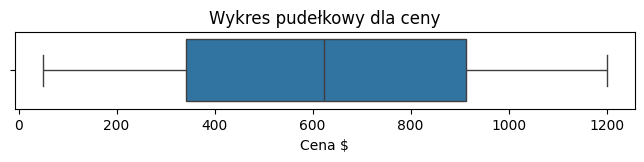

In [414]:
plt.figure(figsize=(8, 1))
price_box = sns.boxplot(x=df['price'])
price_box.set_title('Wykres pudełkowy dla ceny')
price_box.set_xlabel('Cena $')
price_box.get_figure().savefig('pirce_boxplot.png')
price_box.get_figure().show()

###5.1.3. Histogram - pokaże ogólny rozkład cen

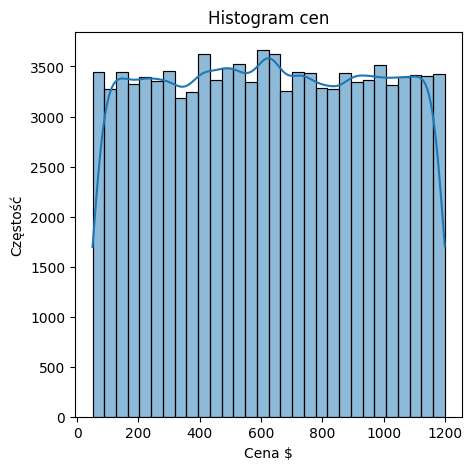

In [415]:
plt.figure(figsize=(5, 5))
price_hist = sns.histplot(df['price'], bins=30, kde=True)
price_hist.set_title('Histogram cen')
price_hist.set_xlabel('Cena $')
price_hist.set_ylabel('Częstość')
price_hist.get_figure().savefig('price_hist.png')
price_hist.get_figure().show()

###5.1.4. Wnioski:
*   Mediana bardzo blisko średniej a kwartyle równomiernie rozłożone wokół nich.
*   Równomierny rozkład wręcz prostokątny.
*   Brak wartości odstających.




##5.2. Analiza kolumny service_fee (Opłata serwisowa)

###5.2.1. Statystyki opisowe

In [416]:
print(df['service_fee'].describe())

count    102050.000000
mean        125.030573
std          66.120043
min          10.000000
25%          68.000000
50%         125.000000
75%         182.000000
max         240.000000
Name: service_fee, dtype: float64


Mediana praktycznie identyczna ze średnią a kwartyle równomiernie rozłożone wokół nich. Wygląda to ponownie na równomierny rozkład wręcz prostokątny.

####5.2.2. Sprawdzenie korelacji ceny z opłatą serwisową

In [417]:
print(df[['service_fee', 'price']].corr())

             service_fee     price
service_fee     1.000000  0.996032
price           0.996032  1.000000


Skoro korelacja wynosi aż ponad 0,99 oznacza to, że service_fee to po prostu liniowa funkcja ceny.

###5.2.3. Sprawdzenie jakim procentem ceny jest w naszych danych opłata serwisowa

In [418]:
procent_fee = (df['service_fee'] / df['price']).mean() * 100
print(f"Opłata serwisowa stanowi średnio: {procent_fee:.2f}% ceny podstawowej.")

Opłata serwisowa stanowi średnio: 20.08% ceny podstawowej.


###5.2.4. Wnioski
*   Ze współczynnika korelacji ceną wynika, że opłata serwisowa to niemal liniowa funkcja ceny. Dlatego rozkład danych wygląda podobnie na prostokątny.
*   Wartości w kolumnie 'service_fee' wynoszą średnio blisko 20% ceny podstawowej.
*   Dla statystyki obie te kolumny niosą taką samą informację.
*   Do dalszej analizy pod kątem sprawdzenia, które czynniki najbardziej wpływają na ceny wynajmu, wykorzystuję wartości z kolumny `price` i pomijam kolumnę `service_fee` i wyliczoną `effective_price` bo będą niosły takie same informacje.



##5.3. Analiza kolumny 'host_identity_verified' (Czy tożsamość gospodarza została zweryfikowana)

###5.3.1. Sprawdzenie unikalnych wartości

In [419]:
print("Rozkład wartości w host_identity_verified:")
print(df['host_identity_verified'].value_counts(dropna=False))
print("-" * 50)

Rozkład wartości w host_identity_verified:
host_identity_verified
unconfirmed    51228
verified       50822
Name: count, dtype: int64
--------------------------------------------------


###5.3.2. Sprawdzam średnią i medianę ceny dla każdej z kategorii

In [420]:
print("Średnia i mediana ceny w zależności od weryfikacji:")
print(df.groupby('host_identity_verified')['price'].agg(['mean', 'median', 'count']))
print("-" * 50)

Średnia i mediana ceny w zależności od weryfikacji:
                              mean  median  count
host_identity_verified                           
unconfirmed             626.861814   625.0  51228
verified                623.847428   623.0  50822
--------------------------------------------------


###5.3.3. Wykres Boxplot ceny w podziale na status weryfikacji

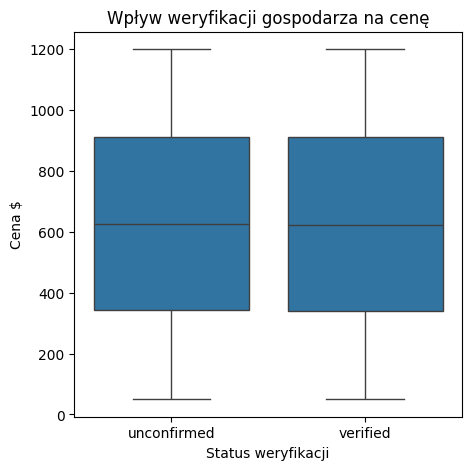

In [421]:
fig_verify, ax = plt.subplots(figsize=(5, 5))
price_host_verified_box = sns.boxplot(x='host_identity_verified', y='price', data=df, ax=ax)
price_host_verified_box.set_title('Wpływ weryfikacji gospodarza na cenę')
price_host_verified_box.set_xlabel('Status weryfikacji')
price_host_verified_box.set_ylabel('Cena $')
plt.show()

###5.3.4. Wnioski
*   Rozkład cen dla gospodarzy zweryfikowanych (verified) oraz niezweryfikowanych (unconfirmed) jest niemal identyczny (mediana odpowiednio: 623 USD i 625 USD)
*   Cecha ta nie wykazuje korelacji z ceną i może zostać pominięta w dalszych analizach.



##5.4. Analiza kolumny 'neighbourhood_group': Szeroki region lub dzielnica, w której znajduje się nieruchomość.

###5.4.1. Rozkład ofert w poszczególnych dzielnicach

In [422]:
print("Liczba ofert w poszczególnych neighbourhood_group:")
print(df['neighbourhood_group'].value_counts(dropna=False))
print("-" * 50)

Liczba ofert w poszczególnych neighbourhood_group:
neighbourhood_group
Manhattan        43567
Brooklyn         41641
Queens           13198
Bronx             2695
Staten Island      949
Name: count, dtype: int64
--------------------------------------------------


###5.4.2. Średnia i mediana ceny dla każdej dzielnicy

In [423]:
print("Statystyki cenowe dla dzielnic:")
print(df.groupby('neighbourhood_group')['price'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False))

Statystyki cenowe dla dzielnic:
                           mean  median  count
neighbourhood_group                           
Bronx                627.857885   630.0   2695
Staten Island        623.988409   627.0    949
Queens               630.190180   626.0  13198
Brooklyn             626.524567   625.0  41641
Manhattan            622.660488   623.0  43567


###5.4.3. Wykres: Boxplot ceny w podziale na dzielnice

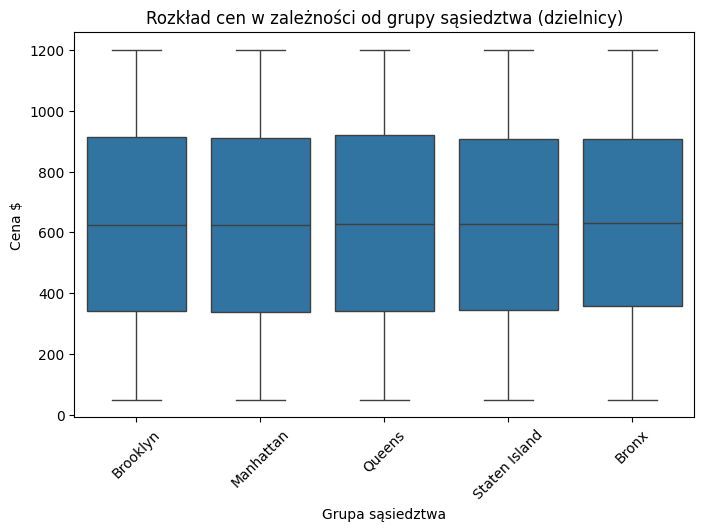

In [424]:
fig_neighborhood, ax = plt.subplots(figsize=(8, 5))
price_by_neighborhood_group_box = sns.boxplot(x='neighbourhood_group', y='price', data=df, ax=ax)

price_by_neighborhood_group_box.set_title('Rozkład cen w zależności od grupy sąsiedztwa (dzielnicy)')
price_by_neighborhood_group_box.set_xlabel('Grupa sąsiedztwa')
price_by_neighborhood_group_box.set_ylabel('Cena $')

plt.xticks(rotation=45) # Obracamy nazwy dzielnic, żeby się nie nakładały
plt.show()

###5.4.4. Wnioski
*   Analiza zmiennej 'neighbourhood_group' przyniosła skrajnie nieintuicyjne rezultaty.
*   Mediana cen we wszystkich pięciu grupach sąsiedztwa jest niemal identyczna i oscyluje w granicach 623–630 USD (np. Manhattan: 623 USD, Bronx: 630 USD).
*   Lokalizacja nieruchomości w danej dzielnicy nie ma wpływu na jej cenę.
*   Należy sprawdzić jak w poszczególnych osiedlach czy sytuacja ma się podobnie.





##5.5. Analiza kolumnu 'neighbourhood': Specyficzna dzielnica, w której znajduje się nieruchomość

###5.5.1. Ogólne statystyki: rozkład, średnia i mediana dla poszczególnych 20 osiedli (z minimalną liczbą ofert 10)

In [425]:
neighbourhood_stats = df.groupby('neighbourhood')['price'].agg(['mean', 'median', 'count'])

print("TOP 10 osiedli z najwyższą medianą cen (tylko te, które mają min. 10 ofert):")
print(neighbourhood_stats[neighbourhood_stats['count'] >= 10].sort_values(by='median', ascending=False).head(10))
print("-" * 50)

print("TOP 10 osiedli z najniższą medianą cen (min. 10 ofert):")
print(neighbourhood_stats[neighbourhood_stats['count'] >= 10].sort_values(by='median', ascending=True).head(10))

TOP 10 osiedli z najwyższą medianą cen (tylko te, które mają min. 10 ofert):
                         mean  median  count
neighbourhood                               
Jamaica Hills      812.904762   971.0     21
Midland Beach      796.176471   957.0     17
Riverdale          768.736842   937.0     19
East Morrisania    764.666667   920.0     21
Shore Acres        805.142857   896.0     21
Bath Beach         723.148936   825.0     47
Morris Park        706.622222   798.0     45
Kew Gardens Hills  690.393939   794.0     66
Gravesend          705.225000   791.0    140
Mill Basin         775.142857   774.5     14
--------------------------------------------------
TOP 10 osiedli z najniższą medianą cen (min. 10 ofert):
                         mean  median  count
neighbourhood                               
Emerson Hill       443.800000   317.0     10
New Dorp Beach     571.363636   323.0     11
Castleton Corners  417.230769   335.0     13
Marble Hill        497.142857   369.5     28
South 

###5.5.2. Wykres Słupkowy Top 5 najtańszych i najdroższych osiedli, które mają przynajmniej 10 ofert, pod względem mediany

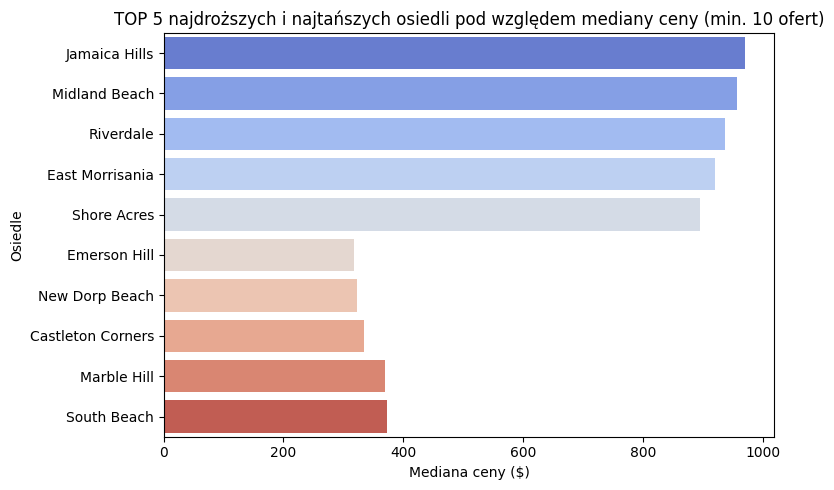

In [426]:
# Przygotowujemy dane: filtrujemy osiedla z min. 10 ofertami
filtered_neighbourhoods = neighbourhood_stats[neighbourhood_stats['count'] >= 10]

# Wybieramy TOP 5 najdroższych i TOP 5 najtańszych pod względem mediany
top5_expensive = filtered_neighbourhoods.sort_values(by='median', ascending=False).head(5)
top5_cheapest = filtered_neighbourhoods.sort_values(by='median', ascending=True).head(5)

# Łączymy je w jedną tabelę do wykresu
extremes = pd.concat([top5_expensive, top5_cheapest]).reset_index()

# Tworzymy figurę i osie
fig_extremes, ax = plt.subplots(figsize=(8, 5))

# Rysujemy wykres słupkowy i przypisujemy do zmiennej
price_by_neighborhood_extremes_bar = sns.barplot(
    x='median',
    y='neighbourhood',
    hue='neighbourhood',
    data=extremes,
    palette='coolwarm',
    legend=False,
    ax=ax
)

# Dodajemy podpisy
price_by_neighborhood_extremes_bar.set_title('TOP 5 najdroższych i najtańszych osiedli pod względem mediany ceny (min. 10 ofert)')
price_by_neighborhood_extremes_bar.set_xlabel('Mediana ceny ($)')
price_by_neighborhood_extremes_bar.set_ylabel('Osiedle')
price_by_neighborhood_extremes_bar.get_figure().savefig('price_by_neighborhood_extremes_bar.png', bbox_inches='tight')


plt.tight_layout()
plt.show()

###5.5.3. Sprawdzenie korelacji ilości ofert w danym osiedlu a ceną

In [427]:
print(neighbourhood_stats[['count', 'median']].corr())

           count    median
count   1.000000  0.016972
median  0.016972  1.000000


Z liczb bliskich zeru wynika, że ilość ofert w danym osiedlu nie ma przełożenia na wysokość cen.

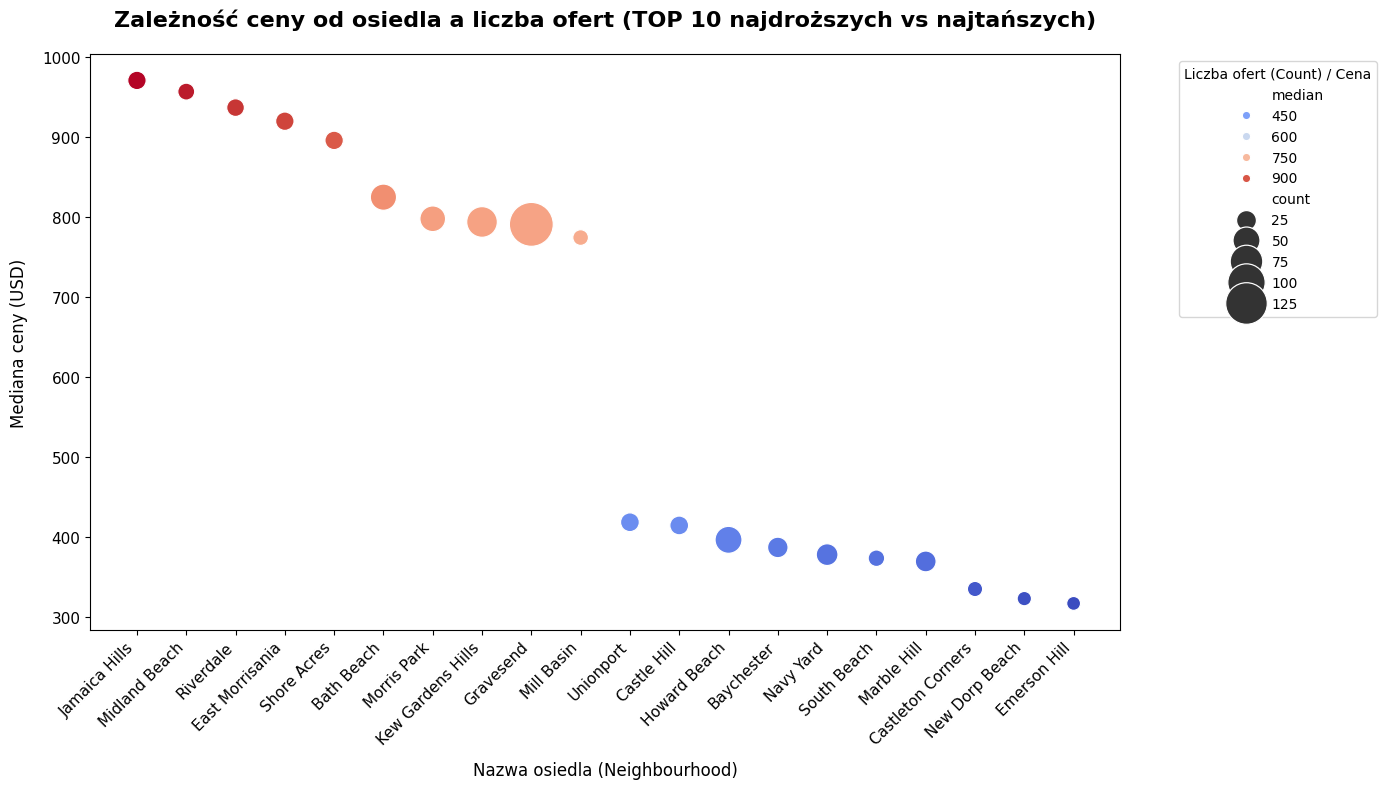

In [428]:
# 1. Przygotowujemy dane (bierzemy Twoje wyniki dla osiedli)
neighborhood_stats = df.groupby('neighbourhood')['price'].agg(['median', 'count']).reset_index()

# Filtrujemy tylko te, które mają minimum 10 ofert (tak jak miałaś w tabeli)
stats_filtered = neighborhood_stats[neighborhood_stats['count'] >= 10]

# Wyciągamy TOP 10 najdroższych i TOP 10 najtańszych
top_expensive = stats_filtered.nlargest(10, 'median')
top_cheapest = stats_filtered.nsmallest(10, 'median')

# Łączymy je w jeden zbiór do wykresu
df_plot = pd.concat([top_expensive, top_cheapest]).sort_values(by='median', ascending=False)

# 2. Tworzymy wykres
plt.figure(figsize=(14, 8))

# Rysujemy bąbelki - wielkość (s) zależy od kolumny 'count'
scatter = sns.scatterplot(
    data=df_plot,
    x='neighbourhood',
    y='median',
    size='count',
    sizes=(100, 1000),  # Ustala min i max wielkość bąbelka, żeby były dobrze widoczne
    hue='median',       # Kolor też zależy od ceny
    palette='coolwarm', # Ładne przejście od niebieskiego (tanio) do czerwonego (drogo)
    legend='brief'
)

# Obracamy nazwy osiedli na osi X, żeby się nie nakładały
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Dodajemy podpisy
plt.title('Zależność ceny od osiedla a liczba ofert (TOP 10 najdroższych vs najtańszych)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nazwa osiedla (Neighbourhood)', fontsize=12, labelpad=10)
plt.ylabel('Mediana ceny (USD)', fontsize=12, labelpad=10)

# Ustawiamy ładną legendę dla wielkości bąbelków
plt.legend(title='Liczba ofert (Count) / Cena', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

###5.5.4. Wnioski
*   Ogólne dzielnice nie różnicują cen (co wyszło nam wcześniej), ale zejście z analizą na poziom konkretnych osiedli (neighbourhood) ujawnia już dysproporcje rynkowe. Mediana cen w najdroższych osiedlach (np. Jamaica Hills - 971 USD, Midland Beach - 957 USD) jest prawie trzykrotnie wyższa niż w osiedlach najtańszych (np. Emerson Hill - 317 USD).
*   Wynik analizy korelacji pomiędzy liczbą ofert w danym osiedlu (count) a medianą cen (median), który wyniósł zaledwie 0.017 wykazuje, że w tych danych wielkość konkurencji w danym osiedlu nie ma znaczenia dla poziomu cen.

##5.6. Analiza kolumny 'distance_to_center': Odległość od centrum NYC



###5.6.1. Sprawdzenie korelacji pomiędzy odległością od centrum a ceną

In [429]:
print(df[['distance_to_center', 'price']].corr())

                    distance_to_center     price
distance_to_center            1.000000  0.006258
price                         0.006258  1.000000


Korelacja cen z odległością od Times Square wyszła praktycznie zerowa.

###5.6.2. Scatterplot jako mapa cen: oś X - długość geograficzna, oś Y - szerokość a kolor: cena (paleta od żółtego (taniej) do fioletu/niebieskiego (drożej))

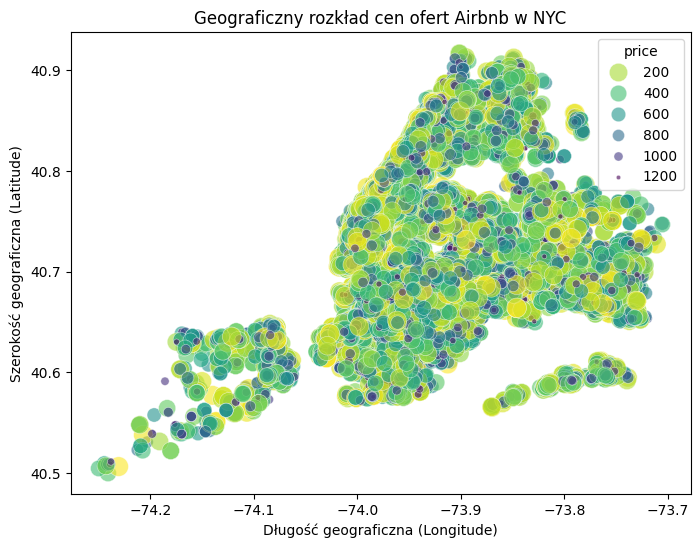

In [430]:
fig, ax = plt.subplots(figsize=(8, 6))
price_distance_to_center_scat = sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price',
    palette='viridis_r',
    alpha=0.6,
    size='price',
    sizes=(200, 10),
    ax=ax
)

ax.set_title('Geograficzny rozkład cen ofert Airbnb w NYC')
ax.set_xlabel('Długość geograficzna (Longitude)')
ax.set_ylabel('Szerokość geograficzna (Latitude)')

fig.savefig('price_distance_to_center_scat.png', bbox_inches='tight')
plt.show()

###5.6.3. Wnioski
*   Korelacja cen z odległością od Times Square (centrum miasta) wyszła prawie zerowa.
*   Wykres geograficzny pokazuje, że tanie oferty są wymieszane z drogimi.
*   Wartość 'neighbourhood' (Osiedle) ma większe znaczenie dla ceny niż współrzędne geograficzne.



##5.7. Analiza kolumny 'instant_bookable': Czy nieruchomość można zarezerwować od ręki

###5.7.1. Sprawdzenie rozkładu danych

In [431]:
print("Liczba ofert w zależności od natychmiastowej rezerwacji:")
print(df['instant_bookable'].value_counts())
print("-" * 50)

Liczba ofert w zależności od natychmiastowej rezerwacji:
instant_bookable
False    51287
True     50763
Name: count, dtype: int64
--------------------------------------------------


###5.7.2. Sprawdzenie średniej i mediany cen dla obu grup

In [432]:
print("Ceny w zależności od instant_bookable:")
print(df.groupby('instant_bookable')['price'].agg(['mean', 'median', 'count']))
print("-" * 50)

Ceny w zależności od instant_bookable:
                        mean  median  count
instant_bookable                           
False             625.190214   625.0  51287
True              625.532780   623.0  50763
--------------------------------------------------


###5.7.3. Wnioski
*   Podział rynku pół na pół: Gospodarze w Nowym Jorku są podzieleni - połowa z nich pozwala na natychmiastowy wynajem, a druga połowa woli najpierw zweryfikować gościa.
*   Opcja rezerwacji "od ręki" nie wpływa na wysokość ceny: Mediana cen w obu przypadkach to około 623-625 USD.




##5.8. Analiza kolumny 'cancellation_policy': Szczegóły dotyczące zasad anulowania rezerwacji

###5.8.1. Sprawdzenie rozkładu danych oraz minimalnej ceny, maksymalnej ceny, średniej i mediany ceny dla poszczególnych opcji anulowania rezerwacji

In [433]:
print("Ceny w zależności od cancellation_policy:")
print(df.groupby('cancellation_policy')['price'].agg(['min', 'max', 'mean', 'median', 'count']))
print("-" * 50)

Ceny w zależności od cancellation_policy:
                      min     max        mean  median  count
cancellation_policy                                         
flexible             50.0  1200.0  626.235865   625.0  33888
moderate             50.0  1200.0  625.208902   623.0  34162
strict               50.0  1200.0  624.597881   624.0  33924
unknown              52.0  1185.0  643.750000   649.5     76
--------------------------------------------------


###5.8.2. Wnioski
*   Równomierny podział rynku: Gospodarze w Nowym Jorku stosują te trzy podejścia niemal w identycznym stopniu (każda opcja to ok. 33% rynku).
*   Polityka anulowania rezerwacji nie różnicuje cen.Mediana cen w każdej z tych trzech głównych grup wynosi praktycznie tyle samo (ok. 623-625 USD).


##5.9. Analiza kolumny 'room_type': Typ oferowanego pokoju (np. Całe mieszkanie/dom, Pokój prywatny).

###5.9.1. Sprawdzenie rozkładu danych oraz minimalnej ceny, maksymalnej ceny, średniej i mediany ceny dla poszczególnych typów oferowanego lokum

In [434]:
print("Ceny w zależności od room_type:")
print(df.groupby('room_type')['price'].agg(['min', 'max', 'mean', 'median', 'count']))
print("-" * 50)

Ceny w zależności od room_type:
                  min     max        mean  median  count
room_type                                               
Entire home/apt  50.0  1200.0  625.233440   624.0  53427
Hotel room       50.0  1193.0  666.391304   643.0    115
Private room     50.0  1200.0  624.951080   623.0  46300
Shared room      50.0  1199.0  634.888587   651.5   2208
--------------------------------------------------


###5.9.2. Wnioski:
*   Ponownie rozkład cen jest podobny w każdym z rodzaju loków do wynajęcia.
*   Rozkład loków w danej ofercie jest zróżnicowany. Najwięcej ofert jest całych domów/mieszkań - 53427, a najmniej hotelowych pokoi - 115.



##5.10. Analiza kolumny 'construction_year': Rok budowy nieruchomości



###5.10.1. Sprawdzenie minimalnej ceny, maksymalnej ceny, średniej i mediany ceny dla poszczególnych lat budowy w bazie

In [435]:
print(df.groupby('construction_year')['price'].agg(['min', 'max', 'mean', 'median', 'count']))
print("-" * 50)

                    min     max        mean  median  count
construction_year                                         
2003               50.0  1200.0  623.336437   624.0   5102
2004               50.0  1199.0  630.020563   634.0   5009
2005               50.0  1200.0  620.323852   622.0   5098
2006               50.0  1199.0  634.925063   637.0   5191
2007               50.0  1200.0  626.189343   627.0   5086
2008               50.0  1200.0  638.640601   636.0   5192
2009               50.0  1200.0  618.618677   621.0   5140
2010               50.0  1200.0  626.651161   625.0   5127
2011               50.0  1200.0  627.246370   623.0   5027
2012               50.0  1200.0  623.141795   623.0   5314
2013               50.0  1200.0  619.104705   612.0   4995
2014               50.0  1200.0  630.976815   630.0   5219
2015               50.0  1200.0  617.371400   607.0   5070
2016               50.0  1200.0  624.784970   624.0   4990
2017               50.0  1200.0  628.816892   621.0   50

###5.10.2. Wnioski:
*   Rok budowy nie wpływa na cenę: Nieruchomości wybudowane w 2003 roku mają podobną medianę cen (624 USD) jak te najnowsze z 2022 roku (635 USD).
*   Równomierny rozkład ofert: Zbiór danych zawiera bardzo zbliżoną liczbę ogłoszeń dla każdego roku z przedziału 2003–2022 (ok. 5 tysięcy ofert na każdy rok).
*   Powtarzalny schemat we wszystkich zmiennych: Podobnie jak w przypadku typu pokoju czy zasad anulowania, wartości skrajne (min 50 i max 1200 USD) są identyczne dla każdego roku budowy.

##5.11. Analiza kolumny 'minimum_nights': Minimalna liczba nocy wymagana do rezerwacji.

###5.11.1. Sprawdzenie korelacji między minimalną liczbą nocy wymaganą do rezerwacji a ceną

In [436]:
print("Korelacja między minimalną liczbą nocy a ceną:")
print(df[['minimum_nights', 'price']].corr())
print("-" * 50)

Korelacja między minimalną liczbą nocy a ceną:
                minimum_nights     price
minimum_nights        1.000000 -0.004244
price                -0.004244  1.000000
--------------------------------------------------


##5.11.2. Wnioski:
* Wymagana liczba nocy nie wpływa na cenę: Współczynnik korelacji między minimalną liczbą nocy a ceną jest bliski zeru (-0.004$).



##5.12. Analiza kolumny number_of_reviews: Łączna liczba recenzji

###5.12.1. Sprawdzenie korelacji między łączną liczbą recenzji a ceną

In [437]:
print("Korelacja między liczbą recenzji a ceną:")
print(df[['number_of_reviews', 'price']].corr())
print("-" * 50)

Korelacja między liczbą recenzji a ceną:
                   number_of_reviews     price
number_of_reviews           1.000000  0.004885
price                       0.004885  1.000000
--------------------------------------------------


###5.12.2. Wnioski:


*   Liczba recenzji nie wpływa na cenę. Współczynnik korelacji bliski zeru.



##5.13. Analiza kolumny 'reviews_per_month': Średnia liczba recenzji na miesiąc.

###5.13.1. Sprawdzenie korelacji średniej liczby recenzji na miesiąc z ceną

In [438]:
print("Korelacja między średnią liczbą recenzji na miesiąc a ceną:")
print(df[['reviews_per_month', 'price']].corr())
print("-" *50)

Korelacja między średnią liczbą recenzji na miesiąc a ceną:
                   reviews_per_month     price
reviews_per_month           1.000000  0.005662
price                       0.005662  1.000000
--------------------------------------------------


###5.13.2. Wnioski:

*   Średnia liczba recenzji na miesiąc nie ma wpływu na wysokość ceny. Współczynnik korelacji bliski zeru.


##5.14. Analiza kolumny 'review_rate_number': Numeryczna ocena na podstawie recenzji

###5.14.1. Sprawdzenie korelacji między Numeryczną oceną na podstawie recenzji a ceną

In [439]:
print("Korelacja między numeryczną oceną na podstawie recenzji a ceną:")
print(df[['review_rate_number', 'price']].corr())
print("-" *50)

Korelacja między numeryczną oceną na podstawie recenzji a ceną:
                    review_rate_number     price
review_rate_number            1.000000 -0.004619
price                        -0.004619  1.000000
--------------------------------------------------


###5.14.2. Wnioski:
*   Numeryczna ocena na podstawie recenzji nie ma wpływu na cenę. Współczynnik korelacji bliski zeru.



##5.15. Analiza kolumny 'calculated_host_listings_count': Łączna liczba ogłoszeń gospodarza

###5.15.1. Sprawdzenie korelacji łącznej liczby ogłoszeń gospodarza z ceną

In [440]:
print("Korelacja między łączną liczbą ogłoszeń gospodarza a ceną:")
print(df[['calculated_host_listings_count', 'price']].corr())
print("-" *50)

Korelacja między łączną liczbą ogłoszeń gospodarza a ceną:
                                calculated_host_listings_count     price
calculated_host_listings_count                        1.000000 -0.000108
price                                                -0.000108  1.000000
--------------------------------------------------


###5.15.2. Wnioski:
*   Łączna liczba ogłoszeń gospodarza nie ma wpływu na cenę. Współczynnik korelacji bliski zeru.


##5.16. Analiza kolumny 'availability_365': Liczba dni, w które nieruchomość jest dostępna do rezerwacji w ciągu roku.

###5.16.1. Sprawdzenie korelacji między Liczbą dni, w które nieruchomość jest dostępna do rezerwacji w ciągu roku

In [441]:
print("Korelacja między łączną liczbą ogłoszeń gospodarza a ceną:")
print(df[['availability_365', 'price']].corr())
print("-" *50)

Korelacja między łączną liczbą ogłoszeń gospodarza a ceną:
                  availability_365     price
availability_365          1.000000 -0.002844
price                    -0.002844  1.000000
--------------------------------------------------


###5.16.2. Wnioski:
*   Liczba dni, w które nieruchomość jest dostępna do rezerwacji w ciągu roku nie ma wpływu na cenę. Współczynnik korelacji bliski zeru.



###5.17. Zapisanie macierzy danych do pliku csv

In [442]:
df.to_csv("Airbnb_NYC_To_Tableau.csv", index=False)

#6. Podsumowanie i stworzenie rekomendacji:

##6.1. Wioski

###6.1.1. Jednostajny rozkład ceny
Głównym i najbardziej zaskakującym odkryciem analizy jest fakt, że bazowa cena wynajmu (price) charakteryzuje się niemal idealnym rozkładem jednostajnym (prostokątnym) w przedziale od 50 do 1200 USD, z medianą wynoszącą 624 USD.
*   Mediana i średnia są niemal identyczne dla każdej badanej zmiennej kategorycznej.
*   Brak wyraźnych wartości odstających (outliers) w dolnych i górnych rejestrach cenowych.

###6.1.2. Opłata serwioswa jako Liniowa Funkcja Ceny
Analiza korelacji wykazała współczynnik na poziomie 0.996 między price a service_fee.

Opłata serwisowa stanowi sztywny odsetek - średnio 20.08% ceny podstawowej.

Z punktu widzenia modelowania i strategii cenowej, kolumna ta nie niesie nowej informacji i została pominięta w dalszych analizach na rzecz samej ceny bazowej.

###6.1.3. Obalenie Założenia Wpływów Lokalizacyjnych i Jakościowych na Cenę (Brak Korelacji)

Wbrew intuicji biznesowej i realiom rynkowym prawdziwego Nowego Jorku, badany zbiór danych wykazuje brak korelacji (współczynniki bliskie 0) ceny z czynnikami, które standardowo definiują rynek nieruchomości:
*   Ogólna Lokalizacja (neighbourhood_group): Mediana cen na elitarnym Manhattanie (623 USD) jest niemal identyczna jak na Bronksie (630 USD) czy Staten Island (627 USD).
*   Geografia (distance_to_center): Korelacja ceny z fizyczną odległością od Times Square wynosi zaledwie 0.006. Tanie i drogie oferty są całkowicie wymieszane geograficznie.
*   Standard i Typ Nieruchomości (room_type, construction_year): Wynajęcie całego apartamentu (Entire home/apt – mediana 624 USD) kosztuje tyle samo co pokój prywatny (Private room – mediana 623 USD). Rok budowy obiektu również nie różnicuje cen (rok 2003: 624 USD vs rok 2022: 635 USD).
*   Zaufanie i Doświadczenie (review_rate_number, host_experience, host_identity_verified): Oferty z oceną 1 gwiazdki, konta niezweryfikowane oraz nowi gospodarze mają takie same profile cenowe jak zweryfikowani weterani rynkowi z setkami opinii.

###6.1.4. Wyjaśnienie Anomalii na Poziomie Osiedli (neighbourhood)

Schodząc na poziom konkretnych osiedli, zidentyfikowano skrajne różnice w medianie cen (od 317 USD w Emerson Hill do 971 USD w Jamaica Hills).

Pogłębiona analiza statystyczna i zastosowanie wykresu bąbelkowego wykazały jednak, że różnice te są anomalią wynikającą z błędu małej próby.

Wszystkie osiedla o skrajnych cenach posiadają krytycznie mały wolumen ofert (poniżej 20-30 wierszy w skali całego zbioru). W przypadku osiedli reprezentatywnych (duże bąbelki, setki ofert), mediana cen zawsze wraca do rynkowego standardu ~625 USD.

##6.2. Rekomendacje dla nowych gospodarzy

Struktura cenowa w tym zbiorze danych jest oderwana od czynników popytowo-podażowych i standardowych reguł rynkowych. Dla nowego gospodarza oznacza to, że nie istnieje 'premia' za lepszy standard, nowszy budynek czy prestiżową dzielnicę. Strategia cenowa powinna opierać się na sztywnym pozycjonowaniu w okolicach średniej rynkowej (~625 USD), natomiast przewagi konkurencyjnej i rentowności należy szukać w optymalizacji kosztów operacyjnych (wybór tańszej w zakupie dzielnicy, np. Bronx/Queens) oraz maksymalizacji obłożenia.